In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Set aesthetics for academic publications
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 14,
    'font.family': 'sans-serif'
})

In [2]:
df_raw = pd.read_csv('evaluations_full_metrics.csv')
df_raw.head(2)

,Evaluation ID,Created At,Query,Model A,Model B,A_Step1_Embedding,A_Step2_Shortlist,A_Step3_Rerank,A_Step4_FetchDB,A_Step5_Aggregate,...,B_Step3_Rerank,B_Step4_FetchDB,B_Step5_Aggregate,B_Step6_Format,B_Total,Results Identical,Evaluator Type,Preference Submitted,Winner,Reasoning
0,2082,2026-05-31 00:59:20.132803+00:00,I need a specialist in maternal-fetal medicine...,512_dim,768_dim,0.068197,0.233275,0.003835,0.012768,0.000652,...,0.0,0.011801,0.000651,0.000144,0.312219,False,llm,True,512_dim,List A is superior because it places Expert 1 ...
1,2081,2026-05-31 00:58:53.478763+00:00,I need a specialist in maternal-fetal medicine...,256_dim,768_dim,0.068197,0.194055,0.004696,0.016720,0.000590,...,0.0,0.011801,0.000651,0.000144,0.312219,False,llm,True,256_dim,Both lists contain the same three experts in t...


In [3]:
df_llm = df_raw[(df_raw['Evaluator Type'] == 'llm') & (df_raw['Preference Submitted'] == True)].copy()
print(f"Using {len(df_llm)} LLM evaluation records.")

Using 1000 LLM evaluation records.


In [4]:
# Extract isolated runs for Model A
df_a = df_llm[['Query', 'Model A', 'A_Step2_Shortlist', 'A_Step3_Rerank']].copy()
df_a.columns = ['Query', 'Dimension', 'Step2_Shortlist', 'Step3_Rerank']

# Extract isolated runs for Model B
df_b = df_llm[['Query', 'Model B', 'B_Step2_Shortlist', 'B_Step3_Rerank']].copy()
df_b.columns = ['Query', 'Dimension', 'Step2_Shortlist', 'Step3_Rerank']

# Combine datasets and calculate total Vector Latency (Shortlisting + Reranking)
df_combined = pd.concat([df_a, df_b], ignore_index=True)
df_combined['Vector_Latency'] = df_combined['Step2_Shortlist'] + df_combined['Step3_Rerank']

# Parse numerical dimensions
df_combined['Dim_Num'] = df_combined['Dimension'].apply(lambda x: int(str(x).split('_')[0]))

# Deduplicate to maintain exactly one record per unique Query and Dimension
df_latency = df_combined.drop_duplicates(subset=['Query', 'Dim_Num']).copy()

print(f"Deduplicated observations: {len(df_latency)} (Expected: 500 for 100 queries x 5 dimensions)")
print(df_latency.groupby('Dim_Num')['Vector_Latency'].describe())

Deduplicated observations: 500 (Expected: 500 for 100 queries x 5 dimensions)
         count      mean       std       min       25%       50%       75%  \
Dim_Num                                                                      
64       100.0  0.104488  0.114281  0.029263  0.042402  0.050827  0.089808   
128      100.0  0.093755  0.113696  0.021191  0.029666  0.038455  0.080067   
256      100.0  0.103911  0.108519  0.023089  0.030716  0.057443  0.122596   
512      100.0  0.127612  0.103049  0.022729  0.052836  0.087025  0.168070   
768      100.0  0.146547  0.100842  0.025079  0.073955  0.112059  0.205614   

              max  
Dim_Num            
64       0.551721  
128      0.487365  
256      0.424463  
512      0.387552  
768      0.419222  


## How does vector truncation affect latency, and is the speedup statistically significant?

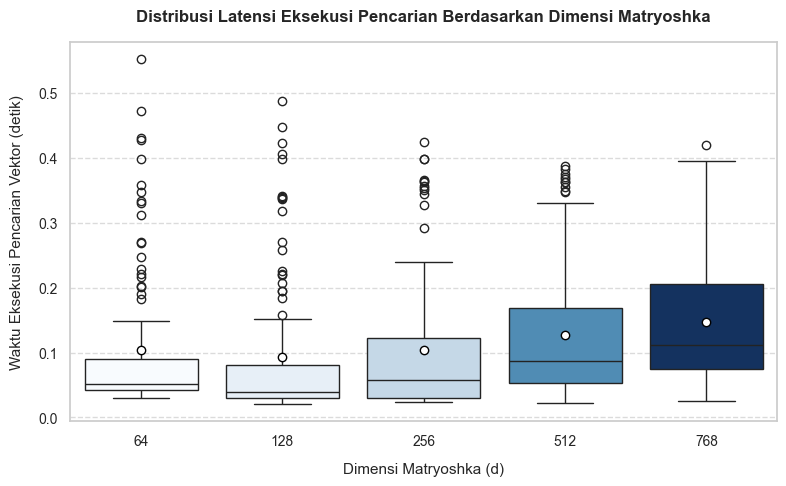

In [5]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_latency,
    x='Dim_Num',
    y='Vector_Latency',
    palette="Blues", 
    hue="Dim_Num",
    legend=False,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize": 6}
)
plt.title('Distribusi Latensi Eksekusi Pencarian Berdasarkan Dimensi Matryoshka', pad=15, fontsize=12, fontweight='bold')
plt.xlabel('Dimensi Matryoshka (d)', labelpad=10, fontsize=11)
plt.ylabel('Waktu Eksekusi Pencarian Vektor (detik)', labelpad=10, fontsize=11)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('mrl_latency_boxplot_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# Perform Shapiro-Wilk test for normality on residuals
grouped_data = [group['Vector_Latency'].values for name, group in df_latency.groupby('Dim_Num')]
f_stat, p_val_anova = stats.f_oneway(*grouped_data)

print(f"One-way ANOVA F-Statistic: {f_stat:.4f}")
print(f"One-way ANOVA p-value: {p_val_anova:.4e}")

if p_val_anova < 0.05:
    print("Result: Highly significant. Reject the null hypothesis. Proceeding to post-hoc analysis...")
else:
    print("Result: No significant difference detected.")

One-way ANOVA F-Statistic: 3.9255
One-way ANOVA p-value: 3.7873e-03
Result: Highly significant. Reject the null hypothesis. Proceeding to post-hoc analysis...


In [7]:
# Pairwise Tukey's HSD test
tukey = pairwise_tukeyhsd(
    endog=df_latency['Vector_Latency'],
    groups=df_latency['Dim_Num'],
    alpha=0.05
)
print(tukey.summary())

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    64    128  -0.0107 0.9562 -0.0526 0.0312  False
    64    256  -0.0006    1.0 -0.0425 0.0413  False
    64    512   0.0231 0.5558 -0.0188  0.065  False
    64    768   0.0421 0.0486  0.0002  0.084   True
   128    256   0.0102  0.964 -0.0317 0.0521  False
   128    512   0.0339 0.1768  -0.008 0.0758  False
   128    768   0.0528 0.0055  0.0109 0.0947   True
   256    512   0.0237 0.5312 -0.0182 0.0656  False
   256    768   0.0426 0.0438  0.0007 0.0845   True
   512    768   0.0189 0.7295  -0.023 0.0608  False
---------------------------------------------------


## Quality Analysis

In [8]:
def compute_elo(matches, K=32, init_elo=1000.0):
    """
    Computes ELO ratings from a series of pairwise matchups.
    """
    dimensions = ['64_dim', '128_dim', '256_dim', '512_dim', '768_dim']
    elos = {dim: init_elo for dim in dimensions}
    
    for _, row in matches.iterrows():
        m_a = row['Model A']
        m_b = row['Model B']
        winner = row['Winner']
        
        # Set actual scores
        if winner == m_a:
            S_a, S_b = 1.0, 0.0
        elif winner == m_b:
            S_a, S_b = 0.0, 1.0
        else: # Draw
            S_a, S_b = 0.5, 0.5
            
        r_a, r_b = elos[m_a], elos[m_b]
        
        # Expected scores
        E_a = 1.0 / (1.0 + 10.0 ** ((r_b - r_a) / 400.0))
        E_b = 1.0 / (1.0 + 10.0 ** ((r_a - r_b) / 400.0))
        
        # ELO updates
        elos[m_a] = r_a + K * (S_a - E_a)
        elos[m_b] = r_b + K * (S_b - E_b)
        
    return elos

### Bootstrapping Tournament matches (Monte Carlo)
To eliminate bias introduced by sequence order and output standard errors for ELO.

In [9]:
n_iterations = 1000
bootstrap_elos = []

for i in range(n_iterations):
    # Sample matches randomly with replacement
    df_sampled = df_llm.sample(frac=1.0, replace=True, random_state=727 + i)
    elos = compute_elo(df_sampled)
    bootstrap_elos.append(elos)

In [10]:
df_boot = pd.DataFrame(bootstrap_elos)
df_boot_summary = pd.DataFrame({
    'Mean_ELO': df_boot.mean(),
    'Std_Error': df_boot.std(),
    'CI_Lower': df_boot.quantile(0.025),
    'CI_Upper': df_boot.quantile(0.975)
}).sort_values('Mean_ELO', ascending=False)

# Parse numerical values for regression/correlation
df_boot_summary['Dim_Num'] = [int(idx.split('_')[0]) for idx in df_boot_summary.index]
df_boot_summary = df_boot_summary.sort_values('Dim_Num')

print("Bootstrapped Elo Rating Results (95% Confidence Interval):")
print(df_boot_summary)

Bootstrapped Elo Rating Results (95% Confidence Interval):
            Mean_ELO  Std_Error    CI_Lower     CI_Upper  Dim_Num
64_dim    882.865446  49.279120  788.259990   980.686760       64
128_dim   995.045616  44.747087  912.983936  1087.326555      128
256_dim  1028.276877  44.034339  947.321570  1111.239212      256
512_dim  1046.746394  44.259348  963.136889  1133.112051      512
768_dim  1047.065667  44.811896  952.731220  1129.765476      768


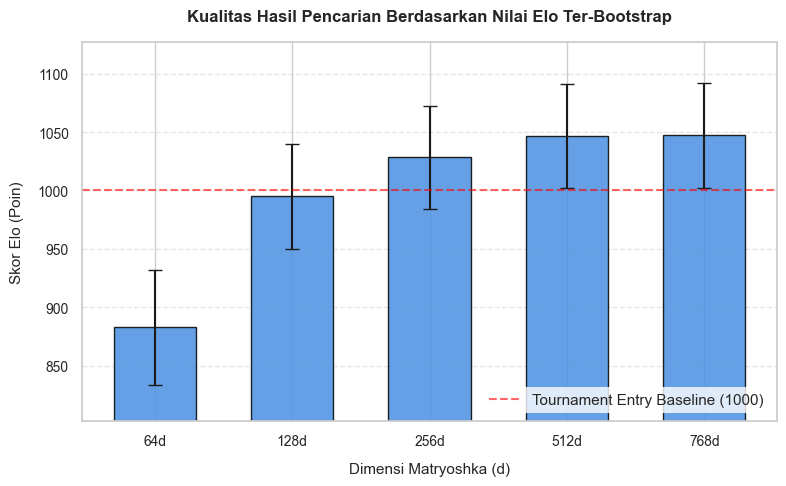

In [11]:
plt.figure(figsize=(8, 5))
bars = plt.bar(
    x=[f"{dim}d" for dim in df_boot_summary['Dim_Num']],
    height=df_boot_summary['Mean_ELO'],
    yerr=df_boot_summary['Std_Error'],
    color='#4a90e2',
    edgecolor='black',
    capsize=5,
    alpha=0.85,
    width=0.6
)
plt.axhline(1000, color='red', linestyle='--', alpha=0.6, label='Tournament Entry Baseline (1000)')

plt.title('Kualitas Hasil Pencarian Berdasarkan Nilai Elo Ter-Bootstrap', pad=15, fontsize=12, fontweight='bold')
plt.xlabel('Dimensi Matryoshka (d)', labelpad=10, fontsize=11)
plt.ylabel('Skor Elo (Poin)', labelpad=10, fontsize=11)

# Atur limit sumbu Y secara dinamis agar visualisasi fluktuasi error bar terlihat jelas
min_y = df_boot_summary['Mean_ELO'].min() - 80
max_y = df_boot_summary['Mean_ELO'].max() + 80
plt.ylim(min_y, max_y)

plt.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('mrl_quality_elo_bar.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
corr_coef, corr_p = stats.spearmanr(df_boot_summary['Dim_Num'], df_boot_summary['Mean_ELO'])
print(f"Spearman's Rank Correlation (Dim_Num vs Mean_ELO): {corr_coef:.6f}")
print(f"Spearman's p-value: {corr_p:.6f}")

Spearman's Rank Correlation (Dim_Num vs Mean_ELO): 1.000000
Spearman's p-value: 0.000000


## The Pareto Efficiency Frontier (Trade-Off Optimization)
Merging ELO scores and execution latency averages to find the optimal deployment model.

In [13]:
# Calculate deterministic mean latencies
mean_latency = df_latency.groupby('Dim_Num')['Vector_Latency'].mean().reset_index()
df_pareto = pd.merge(df_boot_summary, mean_latency, on='Dim_Num')

print("\nPareto Frontier Coordinates:")
for _, row in df_pareto.iterrows():
    print(f"Dimension: {int(row['Dim_Num']):>3} | Latency: {row['Vector_Latency']:.5f}s | ELO: {row['Mean_ELO']:.2f}")


Pareto Frontier Coordinates:
Dimension:  64 | Latency: 0.10449s | ELO: 882.87
Dimension: 128 | Latency: 0.09375s | ELO: 995.05
Dimension: 256 | Latency: 0.10391s | ELO: 1028.28
Dimension: 512 | Latency: 0.12761s | ELO: 1046.75
Dimension: 768 | Latency: 0.14655s | ELO: 1047.07


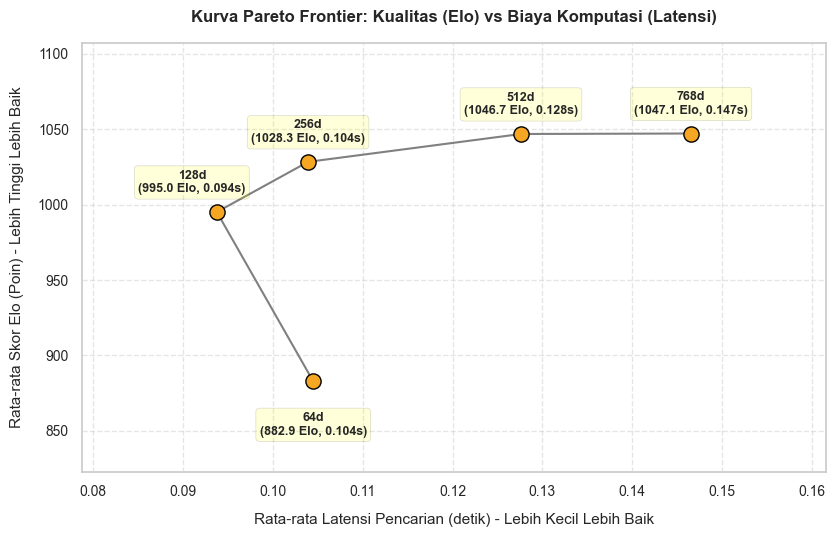

In [14]:
plt.figure(figsize=(8.5, 5.5))

# Plot titik data utama
plt.scatter(
    df_pareto['Vector_Latency'],
    df_pareto['Mean_ELO'],
    color='#f5a623',
    s=120,
    edgecolor='black',
    zorder=3
)

# Hubungkan titik-titik kurva dengan garis tren
plt.plot(
    df_pareto['Vector_Latency'],
    df_pareto['Mean_ELO'],
    color='grey',
    linestyle='-',
    linewidth=1.5,
    zorder=2
)

# Labeli setiap titik dengan penyesuaian posisi (offset) untuk menghindari tabrakan visual
for _, row in df_pareto.iterrows():
    dim = int(row['Dim_Num'])
    x_val = row['Vector_Latency']
    y_val = row['Mean_ELO']
    
    # Aturan offset posisi teks berdasarkan dimensi agar estetis
    if dim == 64:
        xy_text = (0, -22)
        va_align = 'top'
    elif dim == 128:
        xy_text = (-18, 12)
        va_align = 'bottom'
    else:
        xy_text = (0, 12)
        va_align = 'bottom'
        
    plt.annotate(
        f"{dim}d\n({y_val:.1f} Elo, {x_val:.3f}s)",
        (x_val, y_val),
        textcoords="offset points",
        xytext=xy_text,
        ha='center',
        va=va_align,
        fontsize=9,
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.15, ec="black", lw=0.5)
    )

plt.title('Kurva Pareto Frontier: Kualitas (Elo) vs Biaya Komputasi (Latensi)', pad=15, fontsize=12, fontweight='bold')
plt.xlabel('Rata-rata Latensi Pencarian (detik) - Lebih Kecil Lebih Baik', labelpad=10, fontsize=11)
plt.ylabel('Rata-rata Skor Elo (Poin) - Lebih Tinggi Lebih Baik', labelpad=10, fontsize=11)
plt.grid(True, which="both", ls="--", alpha=0.5)

# Perluas sedikit batas sumbu agar anotasi teks tidak terpotong tepi gambar
plt.xlim(df_pareto['Vector_Latency'].min() - 0.015, df_pareto['Vector_Latency'].max() + 0.015)
plt.ylim(df_pareto['Mean_ELO'].min() - 60, df_pareto['Mean_ELO'].max() + 60)

plt.tight_layout()
plt.savefig('mrl_pareto_frontier.png', dpi=300, bbox_inches='tight')
plt.show()

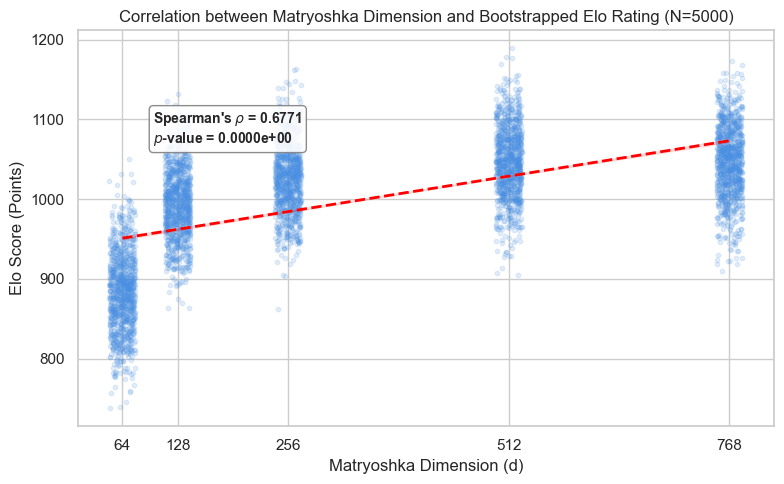

In [15]:
# 1. Reshape data bootstrap (1,000 iterasi x 5 dimensi = 5,000 baris)
df_melted = df_boot.melt(var_name='Dimension', value_name='Elo')
df_melted['Dim_Num'] = df_melted['Dimension'].apply(lambda x: int(x.split('_')[0]))

# 2. Hitung koefisien korelasi Spearman
corr_coef, p_val = stats.spearmanr(df_melted['Dim_Num'], df_melted['Elo'])

# 3. Pengaturan estetika grafik akademik
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# 4. Plot regresi dengan jitter untuk mengatasi overplotting (titik data bertumpuk)
sns.regplot(
    data=df_melted,
    x='Dim_Num',
    y='Elo',
    x_jitter=15,  # Memberikan pergeseran X acak agar sebaran 1.000 titik per dimensi terlihat
    scatter_kws={'alpha': 0.15, 'color': '#4a90e2', 's': 10},
    line_kws={'color': 'red', 'linestyle': '--', 'linewidth': 2}
)

# 5. Tambahkan anotasi statistik Spearman di dalam grafik
plt.text(
    100, 1070, 
    f"Spearman's $\\rho$ = {corr_coef:.4f}\n$p$-value = {p_val:.4e}", 
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9),
    fontsize=10,
    fontweight='bold'
)

# 6. Labeling grafik
plt.title("Correlation between Matryoshka Dimension and Bootstrapped Elo Rating (N=5000)")
plt.xlabel("Matryoshka Dimension (d)")
plt.ylabel("Elo Score (Points)")
plt.xticks([64, 128, 256, 512, 768])
plt.tight_layout()

# 7. Simpan grafik resolusi tinggi untuk laporan skripsi
plt.savefig('mrl_correlation_scatter.png', dpi=300)
plt.show()